# Influential Outlier Metric for PISA data

In [ ]:
%pip install pyreadstat optuna pingouin normflows

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
^C


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("LocalSpark")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

print("Spark version:", spark.version)

Spark version: 4.0.3


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


from joblib import Parallel, delayed
from tqdm import tqdm, trange

from scipy import stats

import optuna

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
import xgboost as xgb
from xgboost.callback import EarlyStopping

from iom import InfluentialOutlierMetric

## MEGB

In [12]:
class MEGB_CPU:
    def __init__(
        self,
        xgb_params=None,
        max_iter=6,
        tol=1e-4,
        random_state=42,
    ):
        xgb_params = dict(xgb_params or {})

        xgb_params.setdefault("learning_rate", 0.05)
        xgb_params.setdefault("max_depth", 6)
        xgb_params.setdefault("subsample", 0.9)
        xgb_params.setdefault("colsample_bytree", 0.9)
        xgb_params.setdefault("objective", "reg:squarederror")

        # CPU settings
        xgb_params.setdefault("tree_method", "hist")
        xgb_params.setdefault("device", "cpu")

        xgb_params.setdefault("nthread", -1)
        xgb_params.setdefault("verbosity", 0)
        xgb_params.setdefault("seed", random_state)

        self.xgb_params = xgb_params
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

        self.booster = None
        self.bhat = None
        self.group_map = None
        self.sigma2_hat = None

    def fit(self, X, y, groups):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)
        groups = np.asarray(groups)

        unique_groups, group_idx = np.unique(
            groups,
            return_inverse=True,
        )
        counts = np.bincount(group_idx).astype(np.float32)

        tr_idx, val_idx = train_test_split(
            np.arange(len(y)),
            test_size=0.2,
            random_state=self.random_state,
        )

        dtrain = xgb.DMatrix(X[tr_idx], label=y[tr_idx])
        dvalid = xgb.DMatrix(X[val_idx], label=y[val_idx])
        dfull = xgb.DMatrix(X)

        bhat = np.zeros(len(unique_groups), dtype=np.float32)
        mu_hat = np.zeros_like(y)
        sigma2 = np.var(y)

        booster = None

        for _ in range(self.max_iter):
            # Fixed-effects update
            dtrain.set_label(
                y[tr_idx] - bhat[group_idx[tr_idx]]
            )
            dvalid.set_label(
                y[val_idx] - bhat[group_idx[val_idx]]
            )

            booster = xgb.train(
                params=self.xgb_params,
                dtrain=dtrain,
                num_boost_round=500,
                evals=[(dvalid, "val")],
                early_stopping_rounds=20,
                xgb_model=booster,
                verbose_eval=False,
            )

            mu_hat[:] = booster.predict(dfull)

            # Random-intercept update
            residuals = y - mu_hat
            bhat_new = (
                np.bincount(group_idx, weights=residuals)
                / counts
            ).astype(np.float32)

            # Residual-variance update
            full_residuals = (
                y - mu_hat - bhat_new[group_idx]
            )
            sigma2_new = np.mean(full_residuals**2)

            converged = (
                abs(sigma2_new - sigma2)
                < self.tol * (sigma2 + 1e-12)
            )

            bhat = bhat_new
            sigma2 = sigma2_new

            if converged:
                break

        self.booster = booster
        self.bhat = bhat
        self.group_map = {
            group: index
            for index, group in enumerate(unique_groups)
        }
        self.sigma2_hat = sigma2

        return self

    def predict(self, X, groups):
        if self.booster is None:
            raise RuntimeError(
                "The model must be fitted before calling predict()."
            )

        X = np.asarray(X, dtype=np.float32)
        groups = np.asarray(groups)

        dmat = xgb.DMatrix(X)
        y_fixed = self.booster.predict(dmat)

        group_idx = np.array(
            [self.group_map.get(group, -1) for group in groups],
            dtype=int,
        )

        random_effects = np.zeros(
            len(groups),
            dtype=np.float32,
        )
        known_groups = group_idx >= 0
        random_effects[known_groups] = self.bhat[
            group_idx[known_groups]
        ]

        return y_fixed + random_effects

In [ ]:
def stratified_by_group_kfold_megb_loss_cpu(
    trial,
    MEGBClass,
    xgb_params,
    max_iter,
    tol,
    X,
    y,
    groups,
    splits,
):
    rmse_list = []

    for fold_id, (train_idx, test_idx) in enumerate(splits):
        X_tr, y_tr = X[train_idx], y[train_idx]
        X_te, y_te = X[test_idx], y[test_idx]
        groups_tr = groups[train_idx]
        groups_te = groups[test_idx]

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            model = MEGBClass(
                xgb_params=xgb_params,
                max_iter=max_iter,
                tol=tol,
                random_state=42 + fold_id,
            )

            model.fit(X_tr, y_tr, groups_tr)
            preds = model.predict(X_te, groups_te)

        rmse = np.sqrt(mean_squared_error(y_te, preds))
        rmse_list.append(rmse)

        # Optuna pruning
        trial.report(rmse, step=fold_id)

        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(rmse_list))


def objective_megb_cpu(trial, X, y, groups, splits):
    xgb_params = {
        # CPU settings
        "device": "cpu",
        "tree_method": "hist",
        "nthread": -1,

        # Tuned parameters
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.02, 0.2
        ),
        "max_depth": trial.suggest_int(
            "max_depth", 3, 8
        ),
        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),
        "min_child_weight": trial.suggest_int(
            "min_child_weight", 1, 10
        ),
        "gamma": trial.suggest_float(
            "gamma", 0.0, 2.0
        ),
    }

    # Keep the EM search relatively narrow
    max_iter = trial.suggest_int("max_iter", 3, 8)
    tol = trial.suggest_float(
        "tol",
        1e-5,
        1e-3,
        log=True,
    )

    return stratified_by_group_kfold_megb_loss_cpu(
        trial=trial,
        MEGBClass=MEGB_CPU,
        xgb_params=xgb_params,
        max_iter=max_iter,
        tol=tol,
        X=X,
        y=y,
        groups=groups,
        splits=splits,
    )


def tune_megb_cpu(
    X,
    y,
    groups,
    n_trials=50,
    n_jobs=8,
):
    X_np = np.asarray(X)
    y_np = np.asarray(y)
    groups_np = np.asarray(groups)

    # Precompute CV splits once
    skf = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42,
    )

    splits = list(
        skf.split(X_np, groups_np)
    )

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=10,
            n_warmup_steps=2,
        ),
    )

    study.optimize(
        lambda trial: objective_megb_cpu(
            trial,
            X_np,
            y_np,
            groups_np,
            splits,
        ),
        n_trials=n_trials,
        n_jobs=n_jobs,
        show_progress_bar=True,
    )

    return study.best_params

## Small model

In [60]:
Data = spark.read.parquet("/content/drive/My Drive/pisa_spark_stu/").select("CNT", 'CNTSCHID', 'CNTSTUID', "PV1MATH", "ESCS").filter(F.col("CNT").isin("SGP", "PHL")).toPandas().dropna()
Data = Data.set_index('CNTSTUID')

In [100]:
Data.shape

(13726, 7)

In [61]:
X = Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH'])
y = Data['PV1MATH']
groups = Data['CNTSCHID']

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.2, random_state=42)

In [62]:
best_megb = tune_megb_cpu(X_train, y_train, groups_train, n_trials=32)

[I 2026-08-17 16:02:59,734] A new study created in memory with name: no-name-dc471e66-d49c-4711-92f5-eb1c609f86b1


  0%|          | 0/32 [00:00<?, ?it/s]

[I 2026-08-17 16:03:03,490] Trial 7 finished with value: 74.4497678165265 and parameters: {'learning_rate': 0.17066385349105878, 'max_depth': 5, 'subsample': 0.7589705944386917, 'colsample_bytree': 0.6160151262498453, 'min_child_weight': 8, 'gamma': 0.7659327355385019, 'max_iter': 3, 'tol': 0.0001703554052378895}. Best is trial 7 with value: 74.4497678165265.
[I 2026-08-17 16:03:03,891] Trial 3 finished with value: 73.40766588446395 and parameters: {'learning_rate': 0.08537076283571689, 'max_depth': 3, 'subsample': 0.6648781089410732, 'colsample_bytree': 0.9208258206926871, 'min_child_weight': 5, 'gamma': 1.2261171813239466, 'max_iter': 3, 'tol': 0.0003909190194271795}. Best is trial 3 with value: 73.40766588446395.
[I 2026-08-17 16:03:12,008] Trial 2 finished with value: 72.59086003835837 and parameters: {'learning_rate': 0.044497396810873335, 'max_depth': 4, 'subsample': 0.6107887562323873, 'colsample_bytree': 0.9985741548721863, 'min_child_weight': 1, 'gamma': 0.11590720193774562, '

In [63]:
megb_params = ['max_iter', 'tol']
xgb_params = {k: v for k, v in best_megb.items() if k not in megb_params}

# Initialize MEGB with unpacked parameters
best_model = MEGB_CPU(
    xgb_params=xgb_params,
    max_iter=best_megb.get('max_iter', 10),
    tol=best_megb.get('tol', 1e-4)
)

best_model.fit(X_train, y_train, groups_train)

In [64]:
print("Test RMSE:", np.sqrt(mean_squared_error(best_model.predict(X_test, groups_test), y_test)))

Test RMSE: 71.54038393367568


### Student level

In [65]:
shap_values = best_model.booster.predict(
    xgb.DMatrix(np.asarray(Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH']).values, dtype=np.float32)),
    pred_contribs=True
)

In [66]:
resid = Data['PV1MATH'] - best_model.predict(Data.drop(columns=['CNTSCHID', "CNT", 'PV1MATH']), Data['CNTSCHID'])

<Axes: ylabel='Count'>

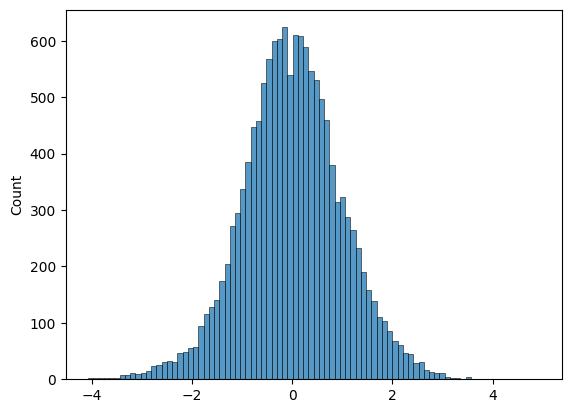

In [67]:
sns.histplot(StandardScaler().fit_transform(resid.values.reshape(-1,1)).ravel())

<Axes: ylabel='Count'>

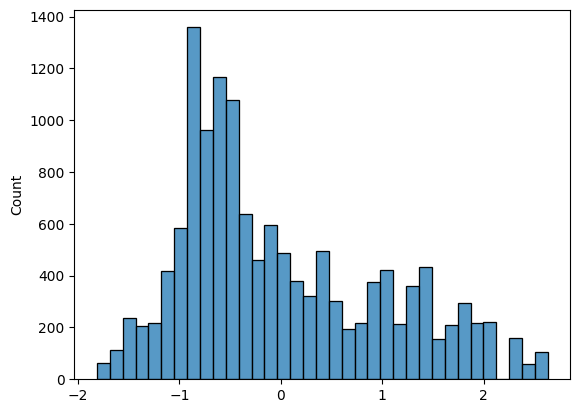

In [68]:
sns.histplot(StandardScaler().fit_transform(shap_values[:,:1]).ravel())

In [72]:
iom = InfluentialOutlierMetric()

In [77]:
results_iom = iom.find_best_lambda(
    StandardScaler().fit_transform(shap_values[:,:1]),
    K=10,
    hidden=10,
    layers=2,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=3,
    num_bins=10,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 1000/1000 [04:28<00:00,  3.72it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.1546

[1b] Stouffer combined normality p-value
     z = 1.0169
     p = 0.1546
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0004
    CvM p-value: 0.0653
    Q mean:      1.0070  expected approx d=1
    Q max:       9.1455
    min tail p:  0.002493
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 1000/1000 [04:30<00:00,  3.70it/s]

--- Whitened mode-normality diagnostics (n=13726, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.0126

[1b] Stouffer combined normality p-value
     z = 2.2385
     p = 0.0126
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0000
    CvM p-value: 0.0480
    Q mean:      0.9859  expected approx d=1
    Q max:       8.0613
    min tail p:  0.004522
Final lambda: 0.0000
Mean test distance: 0.0899
Final weights: [np.float32(1.0)]
Final means: [array([-0.0114], dtype=float32)]
Final scales: [array([0.8224], dtype=float32)]


In [78]:
results_iom_resid = iom.find_best_lambda(
    StandardScaler().fit_transform(resid.values.reshape(-1,1)),
    K=4,
    hidden=4,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=3,
    num_bins=8,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:56<00:00,  8.91it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.2208

[1b] Stouffer combined normality p-value
     z = 0.7694
     p = 0.2208
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.5628
    CvM p-value: 0.4584
    Q mean:      1.0206  expected approx d=1
    Q max:       22.6643
    min tail p:  1.929e-06
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:55<00:00,  8.95it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.1510

[1b] Stouffer combined normality p-value
     z = 1.0321
     p = 0.151
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6058
    CvM p-value: 0.5054
    Q mean:      1.0208  expected approx d=1
    Q max:       22.7546
    min tail p:  1.841e-06
lambda: 0.013123728736940968
cuda


Normalizing flow: 100%|██████████| 500/500 [00:57<00:00,  8.68it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.0988

[1b] Stouffer combined normality p-value
     z = 1.2883
     p = 0.09883
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6944
    CvM p-value: 0.5651
    Q mean:      1.0207  expected approx d=1
    Q max:       22.8390
    min tail p:  1.762e-06
lambda: 0.025561533206507392
cuda


Normalizing flow: 100%|██████████| 500/500 [00:55<00:00,  8.94it/s]


--- Whitened mode-normality diagnostics (n=13726, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 13726  test: Jarque-Bera  pvalue: 0.0462

[1b] Stouffer combined normality p-value
     z = 1.6831
     p = 0.04618
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.7575
    CvM p-value: 0.6236
    Q mean:      1.0209  expected approx d=1
    Q max:       23.0259
    min tail p:  1.598e-06
Final lambda: 0.0131
Mean test distance: 0.0148
Final weights: [np.float32(1.0)]
Final means: [array([-0.0937], dtype=float32)]
Final scales: [array([1.052], dtype=float32)]


In [80]:
iom.IOM(results_iom, results_iom_resid)

,IOM
0,1.448471
1,0.004627
2,0.015428
3,0.800646
4,0.393883
...,...
13721,0.013286
13722,0.003825
13723,0.825471
13724,0.000587


In [81]:
Data['IOM_i'] = iom.IOM_.values
Data['SHAP_z'] = results_iom['chi_z']
Data['resid_z'] = results_iom_resid['chi_z']

In [33]:
iom.find_threshold(p=1)

Threshold at 0.05: 4.761
Threshold at 0.01: 12.990


[4.760901368628315, 12.990352807262584]

In [82]:
Data[Data['IOM_i'] > 12.990352807262584].sort_values(by='IOM_i', ascending=False).shape

(144, 7)

In [83]:
Data[Data['IOM_i'] > 12.990352807262584].sort_values(by='IOM_i', ascending=False).head()

,CNT,CNTSCHID,PV1MATH,ESCS,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,
70202246.0,SGP,70200047.0,364.475,1.0895,87.393142,6.163805,14.178441
70203507.0,SGP,70200104.0,454.227,1.3628,62.884630,7.978248,7.882010
70204980.0,SGP,70200099.0,385.830,1.3463,45.106182,7.978248,5.653645
60800985.0,PHL,60800086.0,523.781,-0.8900,44.912111,5.526395,8.126838
60806859.0,PHL,60800039.0,498.450,-0.7296,44.349990,6.462263,6.862920


### School level

In [84]:
Data_group = pd.concat([pd.Series(best_model.group_map.keys()), pd.Series(best_model.bhat)], axis=1)
Data_group.columns = ['CNTSCHID', 'bhat']

In [85]:
Data_group_final = Data_group.merge(Data[['CNTSCHID', 'CNT']], on='CNTSCHID', how='left').drop_duplicates()
Data_group_final = Data_group_final.rename(columns={'CNT': 'Country'})

Text(0.5, 0, '')

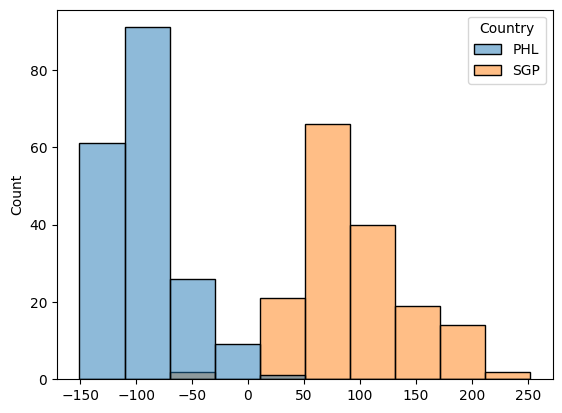

In [87]:
sns.histplot(Data_group_final, x='bhat', hue='Country')
plt.xlabel(None)

In [88]:
iom_sch = InfluentialOutlierMetric()

In [89]:
results_iom_sch_bm = iom_sch.find_best_lambda(
    best_model.bhat.reshape(-1,1),
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[-100, 100],
    scale=[50, 50],
    tail_bound=250,
    num_bins=16,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.62it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 185  test: Jarque-Bera  pvalue: 0.2179
    mode: 1  n: 167  test: Jarque-Bera  pvalue: 0.3213

[1b] Stouffer combined normality p-value
     z = 0.8792
     p = 0.1896
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9054
    CvM p-value: 0.9365
    Q mean:      0.9047  expected approx d=1
    Q max:       7.5601
    min tail p:  0.005968
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.72it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 185  test: Jarque-Bera  pvalue: 0.2210
    mode: 1  n: 167  test: Jarque-Bera  pvalue: 0.3143

[1b] Stouffer combined normality p-value
     z = 0.8856
     p = 0.1879
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.9050
    CvM p-value: 0.9171
    Q mean:      0.9022  expected approx d=1
    Q max:       7.6029
    min tail p:  0.005827
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=352, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 185  test: Jarque-Bera  pvalue: 0.2492
    mode: 1  n: 167  test: Jarque-Bera  pvalue: 0.2697

[1b] Stouffer combined normality p-value
     z = 0.9125
     p = 0.1807
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.7081
    CvM p-value: 0.5038
    Q mean:      0.8742  expected approx d=1
    Q max:       8.2652
    min tail p:  0.004041
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [00:25<00:00, 19.91it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 185  test: Jarque-Bera  pvalue: 0.2613
    mode: 1  n: 167  test: Jarque-Bera  pvalue: 0.2114

[1b] Stouffer combined normality p-value
     z = 1.0189
     p = 0.1541
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.4183
    CvM p-value: 0.2148
    Q mean:      0.8524  expected approx d=1
    Q max:       8.8070
    min tail p:  0.003001
lambda: 0.36787944117144233
cuda


Normalizing flow: 100%|██████████| 500/500 [00:25<00:00, 19.95it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=2) ---

[1] Normality by assigned mode
    mode: 0  n: 186  test: Jarque-Bera  pvalue: 0.2707
    mode: 1  n: 166  test: Jarque-Bera  pvalue: 0.0907

[1b] Stouffer combined normality p-value
     z = 1.3770
     p = 0.08425
     n tests = 2

[2] Pooled Q against chi-square
    KS p-value:  0.0957
    CvM p-value: 0.0470
    Q mean:      0.8222  expected approx d=1
    Q max:       9.5104
    min tail p:  0.002043
Final lambda: 0.1889
Mean test distance: 153.3078
Final weights: [np.float32(0.5017), np.float32(0.4983)]
Final means: [array([-99.7824], dtype=float32), array([99.9872], dtype=float32)]
Final scales: [array([44.8049], dtype=float32), array([51.7358], dtype=float32)]


In [90]:
results_iom_sch_um = iom_sch.find_best_lambda(
    best_model.bhat.reshape(-1,1),
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[100],
    tail_bound=250,
    num_bins=16,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.13it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.2345

[1b] Stouffer combined normality p-value
     z = 0.7241
     p = 0.2345
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.7004
    CvM p-value: 0.5330
    Q mean:      1.0014  expected approx d=1
    Q max:       7.9006
    min tail p:  0.004942
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.36it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.2227

[1b] Stouffer combined normality p-value
     z = 0.7631
     p = 0.2227
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.6625
    CvM p-value: 0.5229
    Q mean:      1.0004  expected approx d=1
    Q max:       7.9293
    min tail p:  0.004864
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=352, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.1473

[1b] Stouffer combined normality p-value
     z = 1.0481
     p = 0.1473
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.3198
    CvM p-value: 0.2409
    Q mean:      0.9949  expected approx d=1
    Q max:       8.0978
    min tail p:  0.004432
lambda: 0.09697196786440505
cuda


Normalizing flow: 100%|██████████| 500/500 [00:25<00:00, 19.74it/s]


--- Whitened mode-normality diagnostics (n=352, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.0792

[1b] Stouffer combined normality p-value
     z = 1.4102
     p = 0.07924
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.1961
    CvM p-value: 0.1397
    Q mean:      0.9835  expected approx d=1
    Q max:       8.3451
    min tail p:  0.003867
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [00:24<00:00, 20.03it/s]

--- Whitened mode-normality diagnostics (n=352, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 352  test: Jarque-Bera  pvalue: 0.0242

[1b] Stouffer combined normality p-value
     z = 1.9732
     p = 0.02424
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0314
    CvM p-value: 0.0245
    Q mean:      0.9732  expected approx d=1
    Q max:       8.5372
    min tail p:  0.00348
Final lambda: 0.0970
Mean test distance: 879.7668
Final weights: [np.float32(1.0)]
Final means: [array([0.1018], dtype=float32)]
Final scales: [array([87.7251], dtype=float32)]


In [91]:
iom_sch.select_flow_by_transport_modes([results_iom_sch_um, results_iom_sch_bm])

{'selected_index': 1,
 'table': [{'index': 0,
   'M': 879.766845703125,
   'n_modes': 1,
   'K_m': 2,
   'rho': np.float64(0.34657359027997264),
   'score': np.float64(880.4599928836849)},
  {'index': 1,
   'M': 153.30783081054688,
   'n_modes': 2,
   'K_m': 5,
   'rho': np.float64(0.34657359027997264),
   'score': np.float64(155.04069876194674)}]}

In [95]:
Data_group_final['bhat_z'] = results_iom_sch_bm['chi_z']

In [98]:
stats.chi2.ppf(0.99, df=1)

np.float64(6.6348966010212145)

In [99]:
Data_group_final[Data_group_final['bhat_z'] > stats.chi2.ppf(0.99, df=1)].sort_values(by='bhat_z', ascending=False)

,CNTSCHID,bhat,Country,bhat_z
7259,70200003.0,252.399612,SGP,8.807044
7167,70200001.0,239.680725,SGP,7.476907


## Full model

In [90]:
Data = spark.read.parquet("/content/drive/MyDrive/pisa_spark_stu/").select("CNT", 'CNTSCHID', 'CNTSTUID', "PV1MATH", "ESCS", "MATHEFF", "MATHPERS").filter(F.col("CNT").isin("SGP", "PHL")).toPandas().dropna()
Data['CNTSCHID'] = Data['CNTSCHID'].astype(str)

In [ ]:
Data['CNT'] = pd.get_dummies(Data['CNT'], drop_first=True).astype(int) #PHL = 0

In [8]:
Data_sch = pd.read_spss("/content/drive/MyDrive/PISA/CY08MSP_SCH_QQQ.SAV")[["CNTSCHID", "PROPMATH"]].dropna()
Data_sch['CNTSCHID'] = Data_sch['CNTSCHID'].astype(str)

In [9]:
Data_final = Data.merge(Data_sch, on="CNTSCHID", how="left").dropna()
Data_final = Data_final.set_index('CNTSTUID')

In [27]:
Data_final

,CNT,CNTSCHID,PV1MATH,ESCS,MATHEFF,MATHPERS,PROPMATH
CNTSTUID,,,,,,,
60806165.0,0,60800182.0,370.444,0.2782,-1.8037,-0.7105,0.1273
60806166.0,0,60800024.0,314.718,-2.6258,0.1777,-0.4530,0.1087
60806167.0,0,60800142.0,268.274,-0.9840,-1.2857,-1.1216,0.1382
60806170.0,0,60800150.0,316.133,-2.3435,-0.2575,-0.6146,0.1429
60806171.0,0,60800009.0,298.137,0.3207,-0.5574,-0.3073,0.1304
...,...,...,...,...,...,...,...
60806158.0,0,60800119.0,392.198,-1.8552,2.2512,0.7827,1.0000
60806160.0,0,60800113.0,395.818,0.2381,-0.0559,0.1930,0.1124
60806161.0,0,60800022.0,406.132,-1.3717,-3.4876,-0.7219,0.1250


In [10]:
X = Data_final.drop(columns=['CNTSCHID', 'PV1MATH'])
y = Data_final['PV1MATH']
groups = Data_final['CNTSCHID']

X_train, X_test, y_train, y_test, groups_train, groups_test = train_test_split(X, y, groups, test_size=0.2, random_state=42)

In [14]:
best_megb = tune_megb_cpu(X_train, y_train, groups_train, n_trials=32)

[I 2026-08-17 18:27:42,411] A new study created in memory with name: no-name-b83c1310-ab05-4815-ad0f-29ba84d0fdf3


  0%|          | 0/32 [00:00<?, ?it/s]

[I 2026-08-17 18:27:50,606] Trial 1 finished with value: 66.80440464244833 and parameters: {'learning_rate': 0.18296539422253233, 'max_depth': 3, 'subsample': 0.8777077670645246, 'colsample_bytree': 0.9118757670366067, 'min_child_weight': 5, 'gamma': 1.747368269382487, 'max_iter': 6, 'tol': 0.0006079237003884827}. Best is trial 1 with value: 66.80440464244833.
[I 2026-08-17 18:27:51,513] Trial 2 finished with value: 70.60180452336802 and parameters: {'learning_rate': 0.19659315791150803, 'max_depth': 6, 'subsample': 0.6367010288969127, 'colsample_bytree': 0.6836612806004448, 'min_child_weight': 5, 'gamma': 1.3358416358346352, 'max_iter': 5, 'tol': 0.0003447752074673424}. Best is trial 1 with value: 66.80440464244833.
[I 2026-08-17 18:27:54,546] Trial 5 finished with value: 66.53040038719068 and parameters: {'learning_rate': 0.05045552973074163, 'max_depth': 5, 'subsample': 0.8811763474151748, 'colsample_bytree': 0.9196866252172455, 'min_child_weight': 6, 'gamma': 0.9538286468461232, 'm

In [15]:
megb_params = ['max_iter', 'tol']
xgb_params = {k: v for k, v in best_megb.items() if k not in megb_params}

# Initialize MEGB with unpacked parameters
best_model = MEGB_CPU(
    xgb_params=xgb_params,
    max_iter=best_megb.get('max_iter', 10),
    tol=best_megb.get('tol', 1e-4)
)

best_model.fit(X_train, y_train, groups_train)

In [16]:
print("Test RMSE:", np.sqrt(mean_squared_error(best_model.predict(X_test, groups_test), y_test)))

Test RMSE: 64.02511825929747


### Student level

In [28]:
shap_values = best_model.booster.predict(
    xgb.DMatrix(np.asarray(Data_final.drop(columns=['CNTSCHID', 'PV1MATH']).values, dtype=np.float32)),
    pred_contribs=True
)

In [29]:
shap_values = pd.DataFrame(shap_values)
shap_values.columns = ['CNT', 'ESCS',"MATHEFF", "MATHPERS", "PROPMATH", 'Intercept']

In [19]:
resid = Data_final['PV1MATH'] - best_model.predict(Data_final.drop(columns=['CNTSCHID', 'PV1MATH']), Data_final['CNTSCHID'])

<Axes: ylabel='Count'>

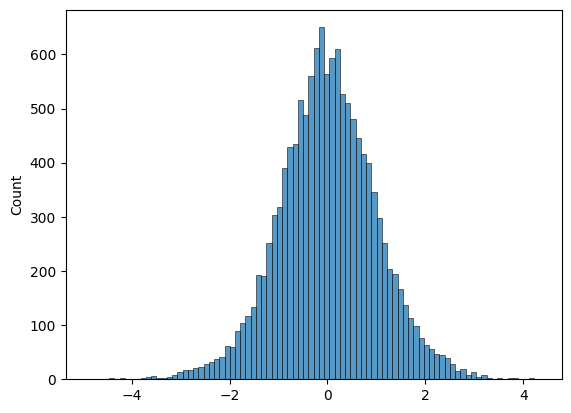

In [20]:
sns.histplot(StandardScaler().fit_transform(resid.values.reshape(-1,1)).ravel())

<Axes: ylabel='Count'>

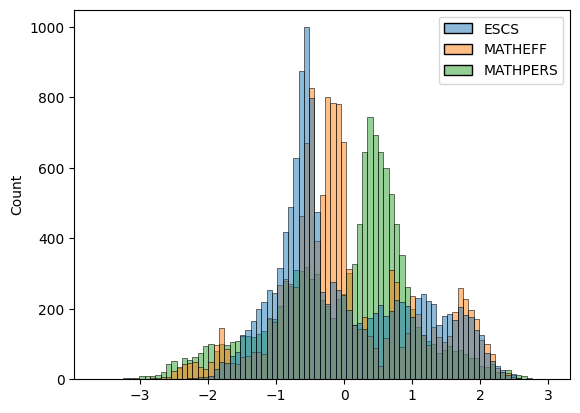

In [30]:
shap_values_stu_s = pd.DataFrame(StandardScaler().fit_transform(shap_values[['ESCS', "MATHEFF", "MATHPERS"]]), columns= ['ESCS', "MATHEFF", "MATHPERS"])
sns.histplot(shap_values_stu_s)

In [31]:
iom = InfluentialOutlierMetric()

In [41]:
results_iom = iom.find_best_lambda(
    shap_values_stu_s.values,
    context=Data_final['CNT'].values,
    K=14,
    hidden=14,
    layers=2,
    epoch=1000,
    loc=[0],
    scale=[1],
    tail_bound=3.8,
    num_bins=13,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 1000/1000 [08:06<00:00,  2.06it/s]


--- Whitened mode-normality diagnostics (n=12955, d=3, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Henze-Zirkler  pvalue: 0.0696

[1b] Stouffer combined normality p-value
     z = 1.4785
     p = 0.06964
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.8873
    CvM p-value: 0.9079
    Q mean:      2.9973  expected approx d=3
    Q max:       21.7987
    min tail p:  7.183e-05
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 1000/1000 [08:05<00:00,  2.06it/s]


--- Whitened mode-normality diagnostics (n=12955, d=3, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Henze-Zirkler  pvalue: 0.0459

[1b] Stouffer combined normality p-value
     z = 1.6865
     p = 0.04585
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.1837
    CvM p-value: 0.0939
    Q mean:      2.9660  expected approx d=3
    Q max:       23.9708
    min tail p:  2.533e-05
Final lambda: 0.0000
Mean test distance: 0.9601
Final weights: [np.float32(1.0)]
Final means: [array([ 0.0084, -0.0157, -0.0246], dtype=float32)]
Final scales: [array([0.9595, 0.9389, 0.9647], dtype=float32)]


In [73]:
results_iom_resid = iom.find_best_lambda(
    StandardScaler().fit_transform(resid.values.reshape(-1,1)),
    context=Data_final['CNT'].values,
    lambdas=np.exp(np.linspace(-5, 1, 10)), 
    K=12,
    hidden=12,
    layers=3,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=4.8,
    num_bins=8,
    torch_seed=42
)

lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [03:09<00:00,  2.64it/s]


--- Whitened mode-normality diagnostics (n=12955, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.9066

[1b] Stouffer combined normality p-value
     z = -1.3201
     p = 0.9066
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0798
    CvM p-value: 0.0663
    Q mean:      1.0284  expected approx d=1
    Q max:       23.1930
    min tail p:  1.465e-06
lambda: 0.013123728736940968
cuda


Normalizing flow: 100%|██████████| 500/500 [03:07<00:00,  2.66it/s]


--- Whitened mode-normality diagnostics (n=12955, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.9013

[1b] Stouffer combined normality p-value
     z = -1.2891
     p = 0.9013
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.0355
    CvM p-value: 0.0773
    Q mean:      1.0278  expected approx d=1
    Q max:       23.5091
    min tail p:  1.243e-06
lambda: 0.025561533206507392
cuda


...

--- Whitened mode-normality diagnostics (n=12955, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.4793

[1b] Stouffer combined normality p-value
     z = 0.0519
     p = 0.4793
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.1372
    CvM p-value: 0.0907
    Q mean:      1.0320  expected approx d=1
    Q max:       25.5337
    min tail p:  4.347e-07
lambda: 0.18887560283756177
cuda


Normalizing flow: 100%|██████████| 500/500 [03:05<00:00,  2.70it/s]


--- Whitened mode-normality diagnostics (n=12955, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.1976

[1b] Stouffer combined normality p-value
     z = 0.8503
     p = 0.1976
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.2572
    CvM p-value: 0.2155
    Q mean:      1.0313  expected approx d=1
    Q max:       25.8441
    min tail p:  3.701e-07
lambda: 0.36787944117144233
cuda


Normalizing flow: 100%|██████████| 500/500 [03:05<00:00,  2.70it/s]


--- Whitened mode-normality diagnostics (n=12955, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 12955  test: Jarque-Bera  pvalue: 0.0225

[1b] Stouffer combined normality p-value
     z = 2.0046
     p = 0.0225
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.7355
    CvM p-value: 0.5315
    Q mean:      1.0285  expected approx d=1
    Q max:       25.9288
    min tail p:  3.542e-07
Final lambda: 0.1889
Mean test distance: 0.0226
Final weights: [np.float32(1.0)]
Final means: [array([-0.0097], dtype=float32)]
Final scales: [array([0.9602], dtype=float32)]


In [74]:
iom.IOM(results_iom, results_iom_resid)

,IOM
0,5.018100
1,0.508597
2,2.564628
3,0.002855
4,0.920686
...,...
12950,0.991599
12951,0.236444
12952,5.397263
12953,0.999187


In [75]:
Data_final['IOM_i'] = iom.IOM_.values
Data_final['SHAP_z'] = results_iom['chi_z']
Data_final['resid_z'] = results_iom_resid['chi_z']

In [76]:
iom.find_threshold(p=3)

Threshold at 0.05: 12.984
Threshold at 0.01: 28.695


[12.9843375948851, 28.695046476162922]

In [77]:
Data_final[Data_final['IOM_i'] > 28.695].sort_values(by='IOM_i', ascending=False)

,CNT,CNTSCHID,PV1MATH,ESCS,MATHEFF,MATHPERS,PROPMATH,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,,,,
70203381.0,1,70200076.0,943.041,1.1072,2.1839,0.9681,0.1244,172.182727,11.695597,14.722013
70206879.0,1,70200102.0,343.089,-0.4264,1.8672,2.7166,0.2347,106.325668,16.966118,6.266941
60806855.0,0,60800074.0,200.888,-3.1790,-0.5502,1.1423,0.1545,105.483547,11.849996,8.901568
70202621.0,1,70200120.0,339.756,-2.0910,0.7990,2.0379,0.3675,100.758567,17.700471,5.692423
70203715.0,1,70200107.0,254.384,-0.3533,2.2559,2.0718,0.1485,95.337345,8.338921,11.432815
...,...,...,...,...,...,...,...,...,...,...
70205563.0,1,70200059.0,368.566,0.9252,-3.4030,0.2371,0.1573,29.394732,10.997961,2.672744
70203973.0,1,70200080.0,433.337,1.3158,-0.0646,-0.4771,0.1364,29.273519,4.910767,5.961090
70201259.0,1,70200003.0,883.094,1.3233,1.4999,0.5737,0.2134,28.943040,10.434574,2.773764


In [78]:
Data_final[Data_final['IOM_i'] > 28.695].sort_values(by='IOM_i', ascending=False).head()

,CNT,CNTSCHID,PV1MATH,ESCS,MATHEFF,MATHPERS,PROPMATH,IOM_i,SHAP_z,resid_z
CNTSTUID,,,,,,,,,,
70203381.0,1,70200076.0,943.041,1.1072,2.1839,0.9681,0.1244,172.182727,11.695597,14.722013
70206879.0,1,70200102.0,343.089,-0.4264,1.8672,2.7166,0.2347,106.325668,16.966118,6.266941
60806855.0,0,60800074.0,200.888,-3.1790,-0.5502,1.1423,0.1545,105.483547,11.849996,8.901568
70202621.0,1,70200120.0,339.756,-2.0910,0.7990,2.0379,0.3675,100.758567,17.700471,5.692423
70203715.0,1,70200107.0,254.384,-0.3533,2.2559,2.0718,0.1485,95.337345,8.338921,11.432815


### School level

<Axes: ylabel='Count'>

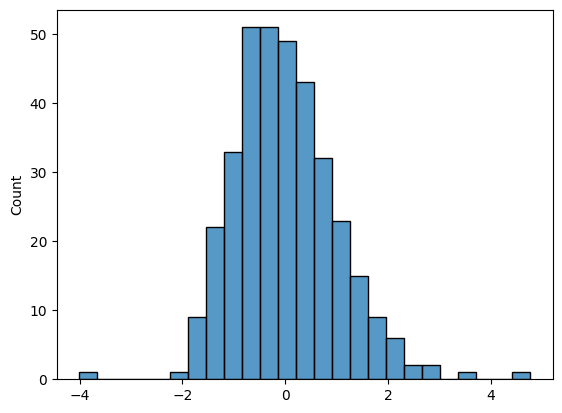

In [79]:
sns.histplot(StandardScaler().fit_transform(best_model.bhat.reshape(-1,1)).ravel())

In [80]:
Data_final['PROPMATH'] = pd.to_numeric(Data_final['PROPMATH'])

In [81]:
Data_final_sch = (
    Data_final
    .groupby("CNTSCHID", as_index=False)
    .agg({
        **{
            col: "mean"
            for col in Data_final.select_dtypes(include="number").columns
            if col != "CNTSCHID"
        },
        "CNT": "first",
    })
)[['CNT', 'CNTSCHID', 'PROPMATH', 'PV1MATH']]

In [82]:
shap_values['CNTSCHID'] = Data_final['CNTSCHID'].values
shap_sch = shap_values[["PROPMATH", 'CNTSCHID']].groupby("CNTSCHID").mean().reset_index()

In [83]:
shap_sch_final = shap_sch.merge(Data_final_sch[['CNT', 'CNTSCHID']], how='left', on='CNTSCHID')

<Axes: ylabel='Count'>

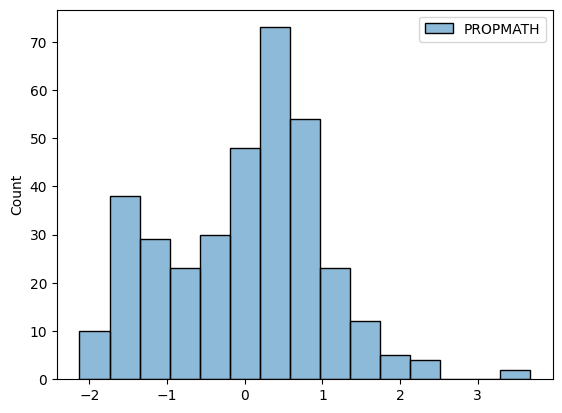

In [84]:
shap_sch_s = pd.DataFrame(StandardScaler().fit_transform(shap_sch_final[['PROPMATH']].values), columns = ["PROPMATH"])
sns.histplot(shap_sch_s)

In [85]:
iom_sch = InfluentialOutlierMetric()

In [86]:
results_iom_sch = iom_sch.find_best_lambda(
    shap_sch_s.values,
    context = shap_sch_final[['CNT']].values,
    lambdas=[10**10],
    K=2,
    hidden=2,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=3,
    num_bins=8,
    torch_seed=42
)

lambda: 10000000000
cuda


Normalizing flow: 100%|██████████| 500/500 [00:27<00:00, 18.41it/s]

--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.8374

[1b] Stouffer combined normality p-value
     z = -0.9839
     p = 0.8374
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.4915
    CvM p-value: 0.4965
    Q mean:      0.9562  expected approx d=1
    Q max:       12.8330
    min tail p:  0.0003406
Final lambda: 10000000000.0000
Mean test distance: 0.0000
Final weights: [np.float32(1.0)]
Final means: [array([-0.], dtype=float32)]
Final scales: [array([1.0227], dtype=float32)]


In [87]:
cnt = pd.DataFrame(pd.Series(list(best_model.group_map.keys()),name='CNTSCHID')).merge(Data_final_sch, on='CNTSCHID')['CNT']

In [88]:
results_iom_sch_resid = iom_sch.find_best_lambda(
    StandardScaler().fit_transform(best_model.bhat.reshape(-1,1)),
    context=cnt.values,
    K=4,
    hidden=4,
    layers=2,
    epoch=500,
    loc=[0],
    scale=[1],
    tail_bound=5,
    num_bins=14,
    torch_seed=42
)

lambda: 0.0
cuda


Normalizing flow: 100%|██████████| 500/500 [00:54<00:00,  9.24it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.6553

[1b] Stouffer combined normality p-value
     z = -0.3996
     p = 0.6553
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9454
    CvM p-value: 0.9823
    Q mean:      0.9855  expected approx d=1
    Q max:       7.6487
    min tail p:  0.005681
lambda: 0.006737946999085467
cuda


Normalizing flow: 100%|██████████| 500/500 [00:53<00:00,  9.27it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.6736

[1b] Stouffer combined normality p-value
     z = -0.4499
     p = 0.6736
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9939
    CvM p-value: 0.9913
    Q mean:      0.9749  expected approx d=1
    Q max:       7.6145
    min tail p:  0.00579
lambda: 0.013123728736940968
cuda


...

--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.1543

[1b] Stouffer combined normality p-value
     z = 1.0183
     p = 0.1543
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9306
    CvM p-value: 0.9594
    Q mean:      0.9641  expected approx d=1
    Q max:       8.1970
    min tail p:  0.004196
lambda: 1.395612425086089
cuda


Normalizing flow: 100%|██████████| 500/500 [00:53<00:00,  9.29it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.0670

[1b] Stouffer combined normality p-value
     z = 1.4984
     p = 0.06701
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9378
    CvM p-value: 0.9441
    Q mean:      0.9710  expected approx d=1
    Q max:       9.3685
    min tail p:  0.002207
lambda: 2.718281828459045
cuda


Normalizing flow: 100%|██████████| 500/500 [00:53<00:00,  9.34it/s]


--- Whitened mode-normality diagnostics (n=351, d=1, K=1) ---

[1] Normality by assigned mode
    mode: 0  n: 351  test: Jarque-Bera  pvalue: 0.0000

[1b] Stouffer combined normality p-value
     z = 4.9815
     p = 3.154e-07
     n tests = 1

[2] Pooled Q against chi-square
    KS p-value:  0.9333
    CvM p-value: 0.8723
    Q mean:      0.9720  expected approx d=1
    Q max:       22.6287
    min tail p:  1.965e-06
Final lambda: 1.3956
Mean test distance: 0.0200
Final weights: [np.float32(1.0)]
Final means: [array([0.1058], dtype=float32)]
Final scales: [array([0.9084], dtype=float32)]


In [92]:
iom_sch.IOM(results_iom_sch, results_iom_sch_resid)

,IOM
0,0.374931
1,0.092385
2,0.010272
3,0.045593
4,0.340823
...,...
346,0.926600
347,2.617707
348,0.103343
349,5.725798


In [93]:
Data_final_sch['IOM_j'] = iom_sch.IOM_.values
Data_final_sch['SHAP_z'] = results_iom_sch['chi_z']
Data_final_sch['resid_z'] = results_iom_sch_resid['chi_z']

In [94]:
iom_test= InfluentialOutlierMetric()
iom_test.find_threshold(p=1)

Threshold at 0.05: 4.761
Threshold at 0.01: 12.990


[4.760901368628315, 12.990352807262584]

In [95]:
Data_final_sch[Data_final_sch['IOM_j'] > 12.990352807262584].sort_values(by=['IOM_j'], ascending=False).head()

,CNT,CNTSCHID,PROPMATH,PV1MATH,IOM_j,SHAP_z,resid_z
188,1,70200001.0,0.1385,728.378907,57.559430,12.833050,4.485249
287,1,70200101.0,0.1384,698.928000,35.630470,10.757748,3.312075
335,1,70200149.0,0.1963,391.408259,18.159510,3.926746,4.624570
187,0,60800188.0,0.1471,453.868615,14.465423,2.693487,5.370518
248,1,70200062.0,0.1475,690.248456,13.709904,5.363343,2.556224
